In [1]:
import os
import pandas as pd

import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel("./data/mCALR-N step data-17mar2026.xlsx", header = 1)
df = df[2:].reset_index(drop = True)
df.columns = ["Batch", "Batch Full Name"] + df.columns[2:].tolist()

In [3]:
[col for col in df.columns if col.startswith("STR2K")]

['STR2K_D05_2_1_PA_HPLC_Concentration',
 'STR2K_D06_2_1_PA_HPLC_Concentration',
 'STR2K_D07_2_1_PA_HPLC_Concentration',
 'STR2K_D08_2_1_PA_HPLC_Concentration',
 'STR2K_D09_2_1_PA_HPLC_Concentration',
 'STR2K_D10_2_1_PA_HPLC_Concentration',
 'STR2K_D11_2_1_PA_HPLC_Concentration',
 'STR2K_D12_2_1_PA_HPLC_Concentration',
 'STR2K_D13_2_1_PA_HPLC_Concentration',
 'STR2K_D14_4_1_PA_HPLC_Concentration']

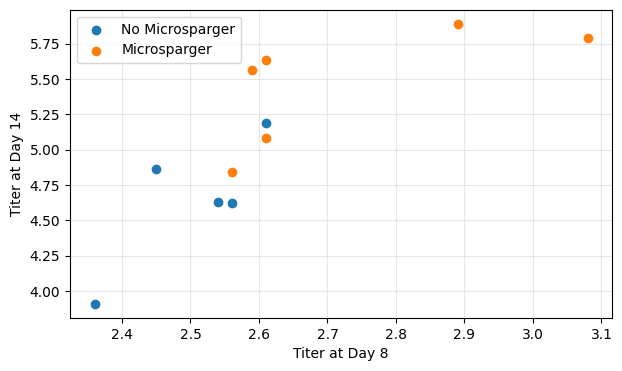

In [4]:
plt.figure(figsize = (7,4))
sub_df = df.head(5)
plt.scatter(
    sub_df["STR2K_D08_2_1_PA_HPLC_Concentration"], 
    sub_df["STR2K_D14_4_1_PA_HPLC_Concentration"],
    label = "No Microsparger"
)
sub_df = df.tail(6)
plt.scatter(
    sub_df["STR2K_D08_2_1_PA_HPLC_Concentration"], 
    sub_df["STR2K_D14_4_1_PA_HPLC_Concentration"],
    label = "Microsparger"
)
plt.ylabel("Titer at Day 14")
plt.xlabel("Titer at Day 8")
plt.legend()
plt.grid(alpha = 0.3)
plt.show()

In [83]:
df.columns

Index(['Batch', 'Batch Full Name', 'CNT_CAT_VAR_MES', 'CNT_SCALAR_MES',
       'CNT_TIME_DATA_MES', 'CNT_TIME_VAR_MES',
       'Generic.Bioreactor.End Culture.Bolus antifoam.Total Qty',
       'Generic.Bioreactor.End Culture.Bolus base.Total Qty',
       'Generic.Bioreactor.End Culture.Cell age at harvest',
       'Generic.Bioreactor.End Culture.Culture duration',
       'Generic.Bioreactor.End Culture.Final VCD',
       'Generic.Bioreactor.End Culture.volume',
       'Generic.Bioreactor.End Culture.PCV',
       'Generic.Bioreactor.Equipment parameters at inoculation.Agitation',
       'Generic.Bioreactor.Equipment parameters at inoculation.Air overlay flow',
       'Generic.Bioreactor.Equipment parameters at inoculation.DO primary probe',
       'Generic.Bioreactor.Equipment parameters at inoculation.DO secondary probe',
       'Generic.Bioreactor.Equipment parameters at inoculation.Temperature',
       'Generic.Bioreactor.Equipment parameters at inoculation.pH primary probe',
       

In [61]:
meta_tail.columns[7:11]

Index(['STR2K_D06_2_1_PA_HPLC_Concentration',
       'STR2K_D07_2_1_PA_HPLC_Concentration',
       'STR2K_D08_2_1_PA_HPLC_Concentration',
       'STR2K_D09_2_1_PA_HPLC_Concentration'],
      dtype='object')

Text(0.5, 1.0, 'Day 8 - 14 Titer\nMin-Max Diff: 0.74')

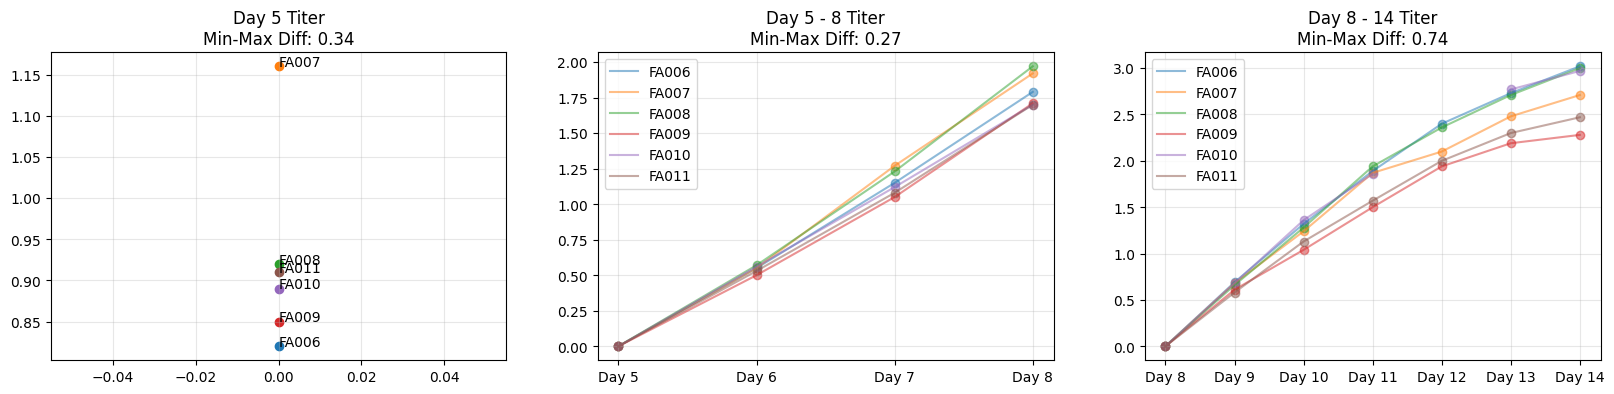

In [81]:
fig, axs = plt.subplots(1, 3, figsize = (20, 4))

ax = axs[0]
# ax.scatter([0] * 6, meta_tail["STR2K_D05_2_1_PA_HPLC_Concentration"])
for row_idx, row in meta_tail.iterrows():
    ax.scatter([0], row["STR2K_D05_2_1_PA_HPLC_Concentration"])
    y = row["STR2K_D05_2_1_PA_HPLC_Concentration"]
    ax.text(0, y, row["batch"])
ax.grid(alpha = 0.3)
min_max_diff = meta_tail["STR2K_D05_2_1_PA_HPLC_Concentration"].max() - meta_tail["STR2K_D05_2_1_PA_HPLC_Concentration"].min()
ax.set_title(f"Day 5 Titer\nMin-Max Diff: {min_max_diff:.2f}")

ax = axs[1]
last_vals = []
for row_idx, row in meta_tail.iterrows():
    y = row[meta_tail.columns[6:10]]
    y = y - y.min()
    ax.plot(range(4), y, label = row["Batch"], alpha = 0.5)
    ax.scatter(range(4), y, alpha = 0.5)
    last_vals.append(y.iloc[-1])
    # ax.text(0, y, row["batch"])
ax.grid(alpha = 0.3)
ax.set_xticks(range(4), [f"Day {i + 5}" for i in range(4)])
ax.legend()
min_max_diff = max(last_vals) - min(last_vals)
ax.set_title(f"Day 5 - 8 Titer\nMin-Max Diff: {min_max_diff:.2f}")

ax = axs[2]
last_vals = []
for row_idx, row in meta_tail.iterrows():
    y = row[meta_tail.columns[9:16]]
    y = y - y.min()
    X = [i for i, val in enumerate(y) if y is not None]
    y = [i for i in y if i is not None]
    ax.plot(X, y, label = row["Batch"], alpha = 0.5)
    ax.scatter(X, y, alpha = 0.5)
    last_vals.append(y[-1])
    # ax.text(0, y, row["batch"])
ax.grid(alpha = 0.3)
ax.set_xticks(range(7), [f"Day {i + 8}" for i in range(7)])
ax.legend()
min_max_diff = max(last_vals) - min(last_vals)
ax.set_title(f"Day 8 - 14 Titer\nMin-Max Diff: {min_max_diff:.2f}")

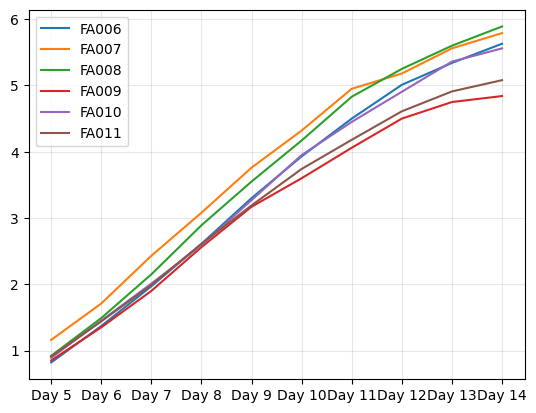

In [42]:
for row_idx, row in df.tail(6).iterrows():
    y = row[[col for col in df.columns if col.startswith("STR2K")]].astype(float).tolist()
    x = [i for i, val in zip(range(5,15), y) if not np.isnan(val)]
    y = [i for i in y if not np.isnan(i)]
    plt.plot(x, y, label = row["Batch"])
    # plt.text(14, y[-1], row["Batch"])
plt.grid(alpha = 0.3)
plt.xticks(range(5, 15), [f"Day {i}" for i in range(5, 15)])
plt.legend()
plt.show()

In [ ]:
df

In [6]:
df.iloc[0].T

Batch                                                                                                   FA001
Batch Full Name                                                              FA001_MCALR N-PROD 2000L_1003145
CNT_CAT_VAR_MES                                                                                             9
CNT_SCALAR_MES                                                                                             25
CNT_TIME_DATA_MES                                                                                         318
CNT_TIME_VAR_MES                                                                                           21
Generic.Bioreactor.End Culture.Bolus antifoam.Total Qty                                                 2.462
Generic.Bioreactor.End Culture.Bolus base.Total Qty                                                    21.128
Generic.Bioreactor.End Culture.Cell age at harvest                                                         36
Generic.Bi

In [86]:
metadata = pd.read_csv("./processed/batch_info.csv").sort_values(by = "batch").reset_index(drop = True)
metadata = pd.merge(metadata, df[["Batch"] + [col for col in df.columns if "STR2K" in col]], left_on = "batch", right_on = "Batch")
metadata[["batch", "STR2K_D05_2_1_PA_HPLC_Concentration", "STR2K_D08_2_1_PA_HPLC_Concentration", "STR2K_D14_4_1_PA_HPLC_Concentration"]].tail(6)

,batch,STR2K_D05_2_1_PA_HPLC_Concentration,STR2K_D08_2_1_PA_HPLC_Concentration,STR2K_D14_4_1_PA_HPLC_Concentration
5,FA006,0.82,2.61,5.63
6,FA007,1.16,3.08,5.79
7,FA008,0.92,2.89,5.89
8,FA009,0.85,2.56,4.84
9,FA010,0.89,2.59,5.56
10,FA011,0.91,2.61,5.08


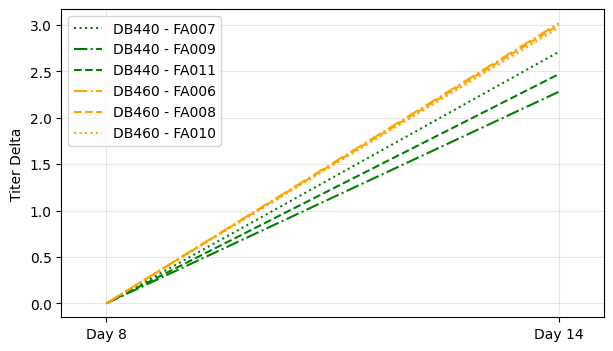

In [72]:
plt.figure(figsize = (7, 4))

meta_tail = metadata.tail(6)
markers = [
    "dotted",
    "dashed",
    "dashdot"
]
for row_idx, row in meta_tail.sort_values(by = ["STR", "batch"]).iterrows():
    ys = row[meta_tail.columns[[-7, -1]]]
    ys = ys - ys.min()
    X = [0, 1]
    c = "green" if row["STR"] == "DB440" else "orange"
    marker = markers[row_idx % 3]
    plt.plot(X, ys, c = c, label = row["STR"] + " - " + row["batch"], linestyle = marker)

plt.xlim(-0.1, 1.1)
plt.xticks([0, 1], ["Day 8", "Day 14"])
plt.legend()
plt.grid(alpha = 0.3)
plt.ylabel("Titer Delta")
plt.show()

In [75]:
meta_tail.iloc[0]

STR                                         DB460
batch                                       FA006
start_date                             2025-12-23
end_date                               2026-01-07
date_diff                                 15 days
Batch                                       FA006
STR2K_D05_2_1_PA_HPLC_Concentration          0.82
STR2K_D06_2_1_PA_HPLC_Concentration          1.37
STR2K_D07_2_1_PA_HPLC_Concentration          1.97
STR2K_D08_2_1_PA_HPLC_Concentration          2.61
STR2K_D09_2_1_PA_HPLC_Concentration           3.3
STR2K_D10_2_1_PA_HPLC_Concentration          3.93
STR2K_D11_2_1_PA_HPLC_Concentration           4.5
STR2K_D12_2_1_PA_HPLC_Concentration          5.01
STR2K_D13_2_1_PA_HPLC_Concentration          5.34
STR2K_D14_4_1_PA_HPLC_Concentration          5.63
Name: 5, dtype: object

In [40]:
(meta_tail["STR2K_D08_2_1_PA_HPLC_Concentration"] - meta_tail["STR2K_D05_2_1_PA_HPLC_Concentration"]).max() - (meta_tail["STR2K_D08_2_1_PA_HPLC_Concentration"] - meta_tail["STR2K_D05_2_1_PA_HPLC_Concentration"]).min()

0.27000000000000046

In [35]:
meta_tail["STR2K_D08_2_1_PA_HPLC_Concentration"].max() - meta_tail["STR2K_D08_2_1_PA_HPLC_Concentration"].min()

0.52

In [37]:
meta_tail["STR2K_D05_2_1_PA_HPLC_Concentration"].max() - meta_tail["STR2K_D05_2_1_PA_HPLC_Concentration"].min()

0.33999999999999997

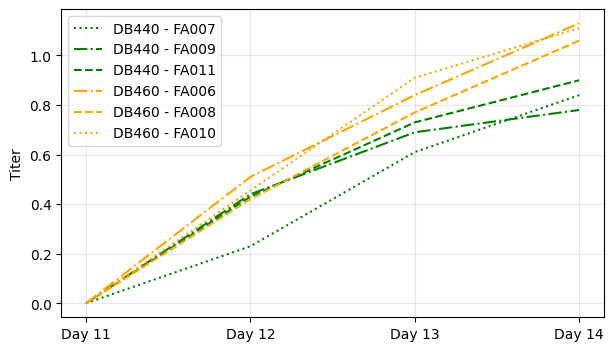

In [96]:
plt.figure(figsize = (7, 4))

meta_tail = metadata.tail(6)
markers = [
    "dotted",
    "dashed",
    "dashdot"
]
for row_idx, row in meta_tail.sort_values(by = ["STR", "batch"]).iterrows():
    ys = row[meta_tail.columns[-4:]]
    ys = ys - ys.min()
    ys = ys.tolist()
    X = range(len(ys))
    X = [i for i in range(len(ys)) if not np.isnan(ys[i])]
    ys= [i for i in ys if not np.isnan(i)]
    c = "green" if row["STR"] == "DB440" else "orange"
    marker = markers[row_idx % 3]
    plt.plot(X, ys, c = c, label = row["STR"] + " - " + row["batch"], linestyle = marker)

# plt.xlim(-0.1, 1.1)
# plt.xticks([0, 1], ["Day 8", "Day 14"])
plt.ylabel("Titer")
plt.xticks(range(4), [f"Day {i + 11}" for i in range(4)])
plt.legend()
plt.grid(alpha = 0.3)
plt.show()

In [36]:
meta_tail.columns[-10:-6]

Index(['STR2K_D05_2_1_PA_HPLC_Concentration',
       'STR2K_D06_2_1_PA_HPLC_Concentration',
       'STR2K_D07_2_1_PA_HPLC_Concentration',
       'STR2K_D08_2_1_PA_HPLC_Concentration'],
      dtype='object')

In [84]:
meta_tail.columns

Index(['STR', 'batch', 'start_date', 'end_date', 'date_diff', 'Batch',
       'STR2K_D05_2_1_PA_HPLC_Concentration',
       'STR2K_D06_2_1_PA_HPLC_Concentration',
       'STR2K_D07_2_1_PA_HPLC_Concentration',
       'STR2K_D08_2_1_PA_HPLC_Concentration',
       'STR2K_D09_2_1_PA_HPLC_Concentration',
       'STR2K_D10_2_1_PA_HPLC_Concentration',
       'STR2K_D11_2_1_PA_HPLC_Concentration',
       'STR2K_D12_2_1_PA_HPLC_Concentration',
       'STR2K_D13_2_1_PA_HPLC_Concentration',
       'STR2K_D14_4_1_PA_HPLC_Concentration'],
      dtype='object')

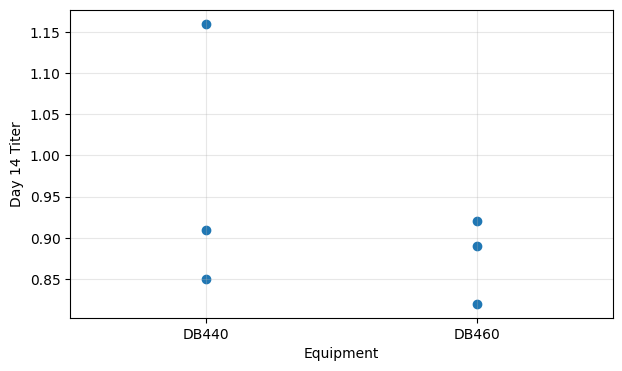

In [85]:
plt.figure(figsize = (7, 4))

meta_tail = metadata.tail(6)

# plt.scatter(
#     [0 if i == "DB440" else 1 for i in meta_tail["STR"]],
#     meta_tail[meta_tail.columns[-1]]
# )
plt.scatter(
    [0 if i == "DB440" else 1 for i in meta_tail["STR"]],
    meta_tail[meta_tail.columns[6]]
)
plt.xlim(-0.5, 1.5)
plt.xticks([0, 1], ["DB440", "DB460"])
plt.ylabel("Day 14 Titer")
plt.xlabel("Equipment")
plt.grid(alpha = 0.3)
plt.show()